In [22]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# 1. Load Clean Data

In [2]:
df_raw = pd.read_csv('clean_data.csv')
df = df_raw.copy()

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# 2. Data Preprocessing

In this phase I use LabelEncoder to labeling `object` columns.

In [4]:
df = df.drop(columns='customerID')

In [5]:
label = LabelEncoder()

In [6]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = label.fit_transform(df[col])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


# 3. Split Data

In this phase I will split data to train and test set using KFold. I decided to drop `TotalCharges` columns beacuse multicollinearity with `tenue` (r=0.83).

In [27]:
y = df['Churn']
X = df.drop(columns=['Churn','TotalCharges'])
kfold = StratifiedKFold(n_splits=5, random_state=7, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=7
)

# 4. Results Functions

I developed Python functions to show confusion matrix and models metrics.

In [9]:
def show_matrix(cm):
        plt.figure(figsize=(4,6))
        sns.heatmap(cm, cmap='inferno', annot=True, fmt='.2f', square=True, cbar=False, xticklabels=['Stay','Churn'], yticklabels=['Stay','Churn'])
        plt.show()
def show_results(cm):
        TN = cm[0,0]
        FP = cm[0,1]
        FN = cm[1,0]
        TP = cm[1,1]
        Precision = TP / (TP + FP)
        Recall = TP / (TP + FN)
        Specificity = TN / (TN + FP)
        Accuracy = (TP + TN) / (TP + TN + FP + FN)
        F1  = (2 * Precision * Recall) / (Precision + Recall)                
        results = print(f"""
        Precision: {Precision}
        Recall: {Recall}
        Specificity: {Specificity}
        Accuracy: {Accuracy}
        F1 Score: {F1}
        """)
    

# 4. Logistic Regression (Baseline Model)

# 4.1 First Model (Default settings)

In [35]:
model_log = make_pipeline(StandardScaler(), LogisticRegression())
model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_test)
cm_log = confusion_matrix(y_test, y_pred_log)

### 4.1.1 Model Results

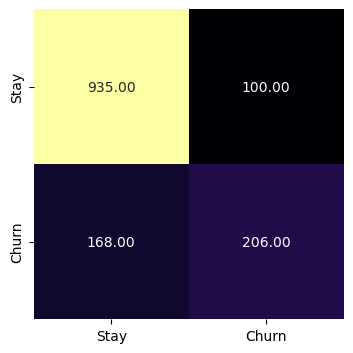


        Precision: 0.673202614379085
        Recall: 0.5508021390374331
        Specificity: 0.9033816425120773
        Accuracy: 0.8097941802696949
        F1 Score: 0.6058823529411765
        


In [36]:
show_matrix(cm_log)
show_results(cm_log)

## 4.2 Hyperparameter Tuning (Accuracy Optimization)

In [32]:
pipe_log_b = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=7))
])
param_grid_log_b = {
    'log_reg__C': [0.001, 0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l1','l2'],
    'log_reg__solver': ['liblinear'],
    'log_reg__class_weight': ['balanced', None]
}
grid_search_log_b = GridSearchCV(estimator=pipe_log_b,
                           param_grid = param_grid_log_b,
                           cv=kfold,
                           n_jobs=1,
                           verbose=1)
grid_search_log_b.fit(X_train, y_train)
print('The best parameters:', grid_search_log_b.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
The best parameters: {'log_reg__C': 0.1, 'log_reg__class_weight': None, 'log_reg__penalty': 'l2', 'log_reg__solver': 'liblinear'}


In [33]:
best_model_log_b = grid_search_log_b.best_estimator_
y_pred_log_b = best_model_log_b.predict(X_test)
cm_log_b = confusion_matrix(y_test, y_pred_log_b)

### 4.2.1 Model Results

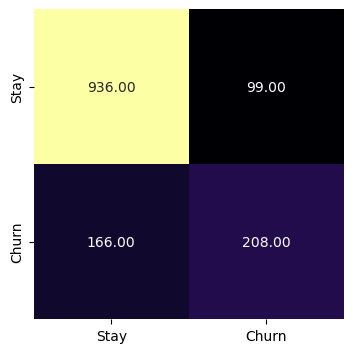


        Precision: 0.6775244299674267
        Recall: 0.5561497326203209
        Specificity: 0.9043478260869565
        Accuracy: 0.8119233498935415
        F1 Score: 0.6108663729809105
        


In [34]:
show_matrix(cm_log_b)
show_results(cm_log_b)

## 4.3 Handling Class Imbalance (F1-Score Optimization)

In [29]:
pipe_log_f = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=7))
])
param_grid_log_f = {
    'log_reg__C': [0.001, 0.01, 0.1, 1, 10],
    'log_reg__penalty': ['l1','l2'],
    'log_reg__solver': ['liblinear'],
    'log_reg__class_weight': ['balanced', None]
}
grid_search_log_f = GridSearchCV(estimator=pipe_log_f,
                           param_grid = param_grid_log_f,
                           cv=kfold,
                                 scoring='f1',
                           n_jobs=1,
                           verbose=1)
grid_search_log_f.fit(X_train, y_train)
print('The best parameters:', grid_search_log_f.best_params_)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
The best parameters: {'log_reg__C': 0.1, 'log_reg__class_weight': 'balanced', 'log_reg__penalty': 'l2', 'log_reg__solver': 'liblinear'}


In [30]:
best_model_log_f = grid_search_log_f.best_estimator_
y_pred_log_f = best_model_log_f.predict(X_test)
cm_log_f = confusion_matrix(y_test, y_pred_log_f)

### 4.3.1 Model Results

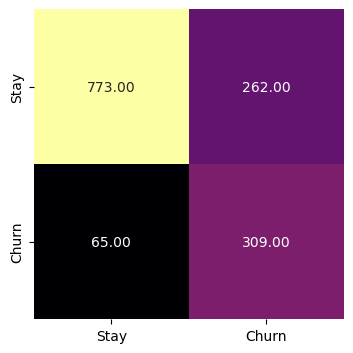


        Precision: 0.5411558669001751
        Recall: 0.8262032085561497
        Specificity: 0.7468599033816425
        Accuracy: 0.7679205110007097
        F1 Score: 0.653968253968254
        


In [31]:
show_matrix(cm_log_f)
show_results(cm_log_f)